In [ ]:
import os
if os.path.ismount('/content/drive'):
    print("Google Drive is mounted.")
else:
    print("Google Drive is not mounted.")

Google Drive is mounted.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pymupdf python-docx tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 15.4 MB/s eta 0:00:00


In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.4 MB/s eta 0:00:00


In [ ]:
# NLP WITH TEXT,DOCX,PDF WITH IMAGE STORAGE
import os
import re
import spacy
import sqlite3
import fitz  # PyMuPDF
import docx
from tqdm import tqdm
import gradio as gr
from PIL import Image
from io import BytesIO

# Load NLP Model
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")

EXCLUDED_SECTIONS = [
    "title page", "copyright", "dedication", "epigraph", "foreword", "preface", "acknowledgement", "introduction", "table of contents", "index",
    "prologue", "glossary", "list of figures", "letter from the author", "author's note", "cast of characters", "map", "timeline", "list of abbreviations"
]

# Load NLP Model
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")

# List of sections to exclude
EXCLUDED_SECTIONS = [
    "title page", "copyright", "dedication", "epigraph", "foreword", "preface", "acknowledgement", "introduction", "table of contents", "index",
    "prologue", "glossary", "list of figures", "letter from the author", "author's note", "cast of characters", "map", "timeline", "list of abbreviations"
]

def should_exclude(text):
    text_lower = text.lower()
    return any(section in text_lower for section in EXCLUDED_SECTIONS)

def remove_excluded_sections(doc):
    """Remove all excluded sections and their content from a DOCX document."""
    new_doc = docx.Document()
    skip = False

    for para in doc.paragraphs:
        text = para.text.strip().lower()

        if text in EXCLUDED_SECTIONS:
            skip = True  # Start skipping content after section title
            continue

        if skip and (not text or text.istitle() or text.isupper()):
            skip = False  # Stop skipping when a new section is reached

        if not skip:
            new_doc.add_paragraph(para.text.strip())

    return new_doc

# Function to check for image-related keywords with refined regex
def refined_figure_detection(text):
    pattern = r'\b(Figure|Fig\.?|Image|Diagram|Graph|Chart|Photo|Map|Illustration|Plot|Snapshot|Drawing|Artwork|Exhibit|Plate|Sketch|Flowchart|Blueprint|Schematic|Infographic|Rendering)\s*(\d+|[A-Z])?(\s*[:.-])?'
    matches = re.findall(pattern, text, flags=re.IGNORECASE)
    return bool(matches)

# Function for context-based detection using spaCy
def context_based_detection(text):
    doc = nlp(text)
    for token in doc:
        if token.text.lower() in ["figure", "fig", "image", "diagram", "chart", "graph", "photo", "map"]:
            next_token = token.nbor(1) if token.i + 1 < len(doc) else None
            if next_token and (next_token.like_num or re.match(r'^[A-Z]$', next_token.text)):
                return True
    return False

# Function to check for heuristic clues in PDFs
def heuristic_pdf_image_check(page, block):
    images = page.get_images(full=True)
    if images:
        block_rect = fitz.Rect(block[0])
        for img in images:
            xref = img[0]
            img_rect = page.get_image_bbox(xref)
            if block_rect.intersects(img_rect):
                return True
    return False

# Function to clean text by removing headers, footers, and extra whitespace
def clean_text(text, header_footer_candidates):
    for candidate in header_footer_candidates:
        text = text.replace(candidate, '')
    text = re.sub(r'\n?\s*Page \d+\s*\n?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\n?\s*\d{1,2}/\d{1,2}/\d{2,4}\s*\n?', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Function to identify common headers/footers across pages
def identify_header_footer(doc):
    line_freq = {}
    for page_num in range(len(doc)):
        page = doc[page_num]
        lines = page.get_text("text").split('\n')
        for line in lines:
            line = line.strip()
            if line:
                line_freq[line] = line_freq.get(line, 0) + 1
    threshold = len(doc) * 0.5
    header_footer_candidates = [line for line, freq in line_freq.items() if freq > threshold]
    return header_footer_candidates

# Function to process docx files
def process_docx(docx_path):
    doc = docx.Document(docx_path)
    doc = remove_excluded_sections(doc)  # Remove specified sections and content
    extracted_data = []
    para_index = 1  # Initialize paragraph index for stored paragraphs

    for paragraph in tqdm(doc.paragraphs, desc="Processing DOCX Paragraphs"):
        text = paragraph.text.strip()
        if not text or should_exclude(text):
            continue

        has_image = False
        if paragraph._element.findall(".//{http://schemas.openxmlformats.org/wordprocessingml/2006/main}drawing"):
            has_image = True

        if refined_figure_detection(text) or context_based_detection(text):
            has_image = True

        cleaned_text = re.sub(r'\s+', ' ', text).strip()
        extracted_data.append((None, para_index, cleaned_text, has_image))
        para_index += 1  # Increment only for stored paragraphs

    return extracted_data

def process_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    extracted_data = []
    header_footer_candidates = identify_header_footer(doc)
    para_index = 1  # Initialize paragraph index for stored paragraphs

    merged_paragraph = ""  # Holds the ongoing paragraph
    last_page_num = None  # Tracks the last page where text was added

    for page_num in tqdm(range(len(doc)), desc="Processing PDF Pages"):
        page = doc[page_num]
        blocks = page.get_text("blocks")

        for block in blocks:
            text = block[4].strip()
            if not text or should_exclude(text):
                continue  # Skip empty or excluded sections

            cleaned_text = clean_text(text, header_footer_candidates)

            if merged_paragraph and last_page_num == page_num - 1:
                # If we detect continuation from the previous page, merge it
                merged_paragraph += " " + cleaned_text
            else:
                # Store the previous paragraph if there's a new distinct one
                if merged_paragraph:
                    extracted_data.append((last_page_num + 1, para_index, merged_paragraph, False))
                    para_index += 1  # Increment only for stored paragraphs

                merged_paragraph = cleaned_text  # Start new paragraph

            last_page_num = page_num  # Track last page where we stored text

    # Store the last paragraph if not already stored
    if merged_paragraph:
        extracted_data.append((last_page_num + 1, para_index, merged_paragraph, False))
        para_index += 1  # Increment only for stored paragraphs

    return extracted_data

# Function to store data in SQLite
def store_in_database(data, db_name="documents.db"):
    print(f"Attempting to store {len(data)} records in {db_name}...")
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS document_data (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            page_number INTEGER,
            paragraph_index INTEGER,
            text TEXT,
            has_image BOOLEAN
        )
    """)
    cursor.executemany("INSERT INTO document_data (page_number, paragraph_index, text, has_image) VALUES (?, ?, ?, ?)", data)
    conn.commit()
    conn.close()

def ensure_output_folder(folder="extracted_images"):
    if not os.path.exists(folder):
        os.makedirs(folder)
    return folder

def extract_images_from_pdf(pdf_path, output_folder):
    doc = fitz.open(pdf_path)
    for page_num in range(len(doc)):
        page = doc[page_num]
        images = page.get_images(full=True)
        for img_index, img in enumerate(images):
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            img_ext = base_image["ext"]
            image_filename = f"{output_folder}/pdf_page_{page_num+1}_img_{img_index+1}.{img_ext}"
            with open(image_filename, "wb") as img_file:
                img_file.write(image_bytes)
            store_image_metadata(image_filename, page_number=page_num+1)

def extract_images_from_docx(docx_path, output_folder):
    doc = docx.Document(docx_path)
    for para_idx, rel in enumerate(doc.part.rels):
        if "image" in doc.part.rels[rel].target_ref:
            image = doc.part.rels[rel].target_part.blob
            image_filename = f"{output_folder}/docx_para_{para_idx+1}.png"
            with open(image_filename, "wb") as img_file:
                img_file.write(image)
            store_image_metadata(image_filename, paragraph_index=para_idx+1)

# Function to process uploaded file
def process_file(file):
    if file is None:
        return "No file uploaded."

    file_path = file.name
    output_folder = ensure_output_folder()

    extracted_data = []

    if file_path.lower().endswith(".pdf"):
        extracted_data = process_pdf(file_path)
        extract_images_from_pdf(file_path, output_folder)  # Extract images and store metadata
    elif file_path.lower().endswith(".docx"):
        extracted_data = process_docx(file_path)
        extract_images_from_docx(file_path, output_folder)  # Extract images and store metadata
    else:
        return "Unsupported file format! Only PDF and DOCX are supported."

    if extracted_data:
        store_in_database(extracted_data)  # Store extracted text in `documents.db`

    return "Processing complete! Extracted text stored in 'documents.db' and images stored in 'extracted_images' with metadata in 'images.db'."

# Function to process manually entered text
def process_text_input(text):
    if not text.strip():
        return "No text entered."

    has_image = False
    if refined_figure_detection(text) or context_based_detection(text):
        has_image = True

    cleaned_text = re.sub(r'\s+', ' ', text).strip()
    extracted_data = [(None, None, cleaned_text, has_image)]

    store_in_database(extracted_data)
    return "Processing complete! Extracted text has been stored in 'documents.db'."

def store_image_metadata(image_name, page_number=None, paragraph_index=None, db_name="images.db"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS image_data (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            image_name TEXT,
            page_number INTEGER,
            paragraph_index INTEGER
        )
    """)
    cursor.execute("INSERT INTO image_data (image_name, page_number, paragraph_index) VALUES (?, ?, ?)",
                   (image_name, page_number, paragraph_index))
    conn.commit()
    conn.close()

# Function to remove uploaded file
def remove_file():
    return None, "File removed successfully."

# Function to remove text from input field
def remove_text():
    return "", "Text removed successfully."

# Gradio Interface
with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue", secondary_hue="cyan"), css="""
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600&display=swap');

    .gradio-container {
        background-color: #e0f2ff; /* Light Blue */
        padding: 10px;
        font-family: 'Poppins', sans-serif;
    }
    .gr-box, .gr-panel {
        background-color: #f0f8ff; /* Alice Blue */
        border-radius: 12px;
        padding: 5px;
        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
        max-height: 400px;
        overflow-y: auto;
        font-family: 'Poppins', sans-serif;
    }
    .gr-button {
        border-radius: 8px;
        background-color: #4682b4 !important; /* Steel Blue */
        color: white !important;
        font-family: 'Poppins', sans-serif;
    }
    .footer {
        display: none;
    }
""") as demo:
    gr.Markdown("# ✨ text2pix")
    with gr.Tab("Upload File"):
        file_input = gr.File(label="Upload PDF or DOCX File", file_types=[".pdf", ".docx"])
        process_button = gr.Button("Process File")
        remove_file_button = gr.Button("Remove File")

    with gr.Tab("Enter Text"):
        text_input = gr.Textbox(label="Enter text manually", lines=5)
        text_process_button = gr.Button("Process Text")
        remove_text_button = gr.Button("Remove Text")

    output_text = gr.Textbox(label="Status", interactive=False)

    process_button.click(fn=process_file, inputs=file_input, outputs=output_text)
    remove_file_button.click(fn=remove_file, inputs=[], outputs=[file_input, output_text])
    text_process_button.click(fn=process_text_input, inputs=text_input, outputs=output_text)
    remove_text_button.click(fn=remove_text, inputs=[], outputs=[text_input, output_text])

demo.launch(share=True)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8860dd9a9cac32d793.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (

In [ ]:
!pip install ipython-sql

In [ ]:
%load_ext sql

In [ ]:
%sql sqlite:///documents.db

In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("documents.db")   # image.db

# Read table data into a Pandas DataFrame
df = pd.read_sql_query("SELECT * FROM document_data;", conn)    # image_data

# Display the data
print(df)

# Close the connection
conn.close()

   id page_number  paragraph_index  \
0   1        None                1   
1   2        None                2   
2   3        None                3   
3   4        None                4   

                                                text  has_image  
0  Computers consist of various devices that help...          0  
1  Input Devices: These allow users to enter data...          0  
2  Output Devices: These devices display or provi...          1  
3  Processing Devices: These handle data processi...          0  


In [ ]:
import sqlite3

DB_NAME = "documents.db"

conn = sqlite3.connect(DB_NAME)
cursor = conn.cursor()

cursor.execute("SELECT * FROM document_data")
rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

(1, None, 1, 'Diwali - The Festival of Lights-Diwali is a Hindu festival symbolizing the victory of light over darkness and good over evil. It is celebrated with diyas (oil lamps), fireworks, rangoli, and prayers to Goddess Lakshmi for prosperity. Families exchange sweets, decorate their homes, and enjoy festive gatherings.', 0)
(2, None, 2, 'Christmas - The Season of Joy-Christmas is a Christian festival celebrating the birth of Jesus Christ on December 25th. It is marked by decorating Christmas trees, exchanging gifts, singing carols, and attending church services. Families gather for feasts, and children eagerly await Santa Claus and his presents. Figure below is Christmas.', 1)
(3, None, 3, 'Ramadan - The Month of Fasting & Reflection- Ramadan is the Islamic holy month of fasting, prayer, and self-discipline, observed from dawn to dusk. Muslims break their fast at iftar with dates and traditional foods and dedicate time to charity and worship. The month ends with Eid al-Fitr, a joy

In [ ]:
# DELETION
import sqlite3
import pandas as pd

conn = sqlite3.connect("documents.db")
cursor = conn.cursor()

cursor.execute("DELETE FROM document_data;")
cursor.execute("DELETE FROM sqlite_sequence WHERE name='document_data';")

conn.commit()

df = pd.read_sql_query("SELECT * FROM document_data;", conn)
print(df)

conn.close()

Empty DataFrame
Columns: [id, page_number, paragraph_index, text, has_image]
Index: []


In [ ]:
# DELETION OF ROWS IN TABLE
import sqlite3
import pandas as pd

conn = sqlite3.connect("documents.db")
cursor = conn.cursor()

# Delete rows where paragraph_index is 1, 3, or 5
cursor.execute("DELETE FROM document_data WHERE paragraph_index in (1,3,5);")

conn.commit()

# Verify by reading the remaining data
df = pd.read_sql_query("SELECT * FROM document_data;", conn)
print(df)

conn.close()

   id page_number  paragraph_index  \
0   2        None                2   
1   4        None                4   
2   6        None                6   

                                                text  has_image  
0  Tsunamis are massive ocean waves triggered by ...          0  
1  Earthquakes occur due to the sudden release of...          0  
2  Volcanic eruptions occur when magma, gases, an...          0  


In [ ]:
!pip install huggingface_hub

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 10.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
!pip install --upgrade pip setuptools wheel

In [ ]:
!pip uninstall -y scipy
!pip install --no-cache-dir scipy

Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 207.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.2 which is incompatible.


In [ ]:
!pip install --no-cache-dir gensim scikit-learn numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 116.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2


In [ ]:
# CHATBOT
import sqlite3
import re
import time
import spacy
from math import ceil
from huggingface_hub import InferenceClient
from PIL import Image  # For displaying images
from io import BytesIO
import numpy as np
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity
import gensim.downloader as api
import sys
import os

# Load English NLP model
nlp = spacy.load("en_core_web_sm")

# Add Google Drive library path
sys.path.append('/content/drive/MyDrive/colab_libs')

# Define path to save/load the Word2Vec model
model_path = '/content/drive/MyDrive/word2vec-google-news-300/word2vec-google-news-300.model'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Check if model exists in Drive, else upload/download
if os.path.exists(model_path):
    print("Loading Word2Vec model from Google Drive...")
    model = KeyedVectors.load(model_path)
    print("Model loaded successfully.")
else:
    print("Downloading Word2Vec model...")
    model = api.load("word2vec-google-news-300")
    model.save(model_path)
    print("Model saved to Google Drive.")

# Hugging Face API Key (Replace with your key)
API_KEY = "your_api_key"
MODEL = "stabilityai/stable-diffusion-3.5-large"  #stabilityai/stable-diffusion-xl-base-1.0    stabilityai/stable-diffusion-3.5-large-turbo

client = InferenceClient(model=MODEL, token=API_KEY)

# SQLite Database
DB_NAME = "documents.db"

def fetch_paragraphs_without_images():
    """Fetch paragraphs where has_image = 0."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT id, text FROM document_data where has_image=0")
    paragraphs = cursor.fetchall()
    conn.close()
    return paragraphs

def extract_context(sentence):
    """Tokenize and extract words from a sentence (simple example)."""
    return sentence.split()

def icf_algorithm(sentences):
    """Apply Initial Context First (ICF) ensuring correct subject-verb context."""
    n = len(sentences)
    S_input = sentences[:]
    S_cxt = []
    W_cxt = []

    for i in range(n):
        sentence_context = extract_context(sentences[i])
        S_cxt.append(sentence_context)
        W_cxt.append(sentence_context)

    for i in range(n):
        S_cxt[i] += W_cxt[0]
        S_input[i] = " ".join(S_cxt[i])

    return " ".join(S_input)

def rcf_algorithm(sentences, delta):
    """Apply Region Context First (RCF) with a dynamic threshold."""
    n = len(sentences)
    S_input = sentences[:]
    S_cxt = []
    W_cxt = []

    for i in range(n):
        sentence_context = extract_context(sentences[i])
        S_cxt.append(sentence_context)
        W_cxt.append(sentence_context)

    for i in range(n):
        if n > delta:
            S_cxt[i] += W_cxt[i % delta]
        else:
            S_cxt[i] += W_cxt[0]
        S_input[i] = " ".join(S_cxt[i])

    return " ".join(S_input)

def calculate_similarity(context1, context2, model):
    """Calculate cosine similarity between two contexts using Word2Vec embeddings."""
    vector1 = sentence_to_vector(context1, model)
    vector2 = sentence_to_vector(context2, model)

    if vector1 is not None and vector2 is not None:
        return cosine_similarity([vector1], [vector2])[0][0]
    return 0

def sentence_to_vector(sentence, model):
    """Convert a sentence into a vector by averaging Word2Vec embeddings."""
    vectors = [model[word] for word in sentence if word in model.key_to_index]
    return np.mean(vectors, axis=0) if vectors else None

def scrm_algorithm(sentences, delta):
    """Apply Semantic Context Recognition and Modification (SCRM)."""
    n = len(sentences)
    S_input = sentences[:]
    S_cxt = []
    W_cxt = []
    cxtIndex = 1

    for i in range(n):
        sentence_context = extract_context(sentences[i])
        S_cxt.append(sentence_context)
        W_cxt.append(sentence_context)

    for i in range(n - 1):
        similarity = calculate_similarity(W_cxt[i], W_cxt[i + 1], model)

        if similarity > delta:
            S_cxt[i] += W_cxt[cxtIndex - 1]
        else:
            cxtIndex = i + 1
            S_cxt[i] += W_cxt[cxtIndex - 1]

        S_input[i] = " ".join(S_cxt[i])

    return " ".join(S_input)

def generate_image_with_retry(prompt, output_filename, max_retries=5):
    """Generate an image with retries and return the output filename."""
    retries = 0
    while retries < max_retries:
        try:
            image = client.text_to_image(prompt, width=512, height=512)
            image_bytes = BytesIO()
            image.save(image_bytes, format="PNG")
            with open(output_filename, "wb") as f:
                f.write(image_bytes.getvalue())
            print(f"Image saved as {output_filename}")
            return output_filename
        except Exception as e:
            print(f"Error: {e}. Retrying in {10 * (retries + 1)} seconds...")
            time.sleep(10 * (retries + 1))
            retries += 1
    print("Max retries reached. Skipping this request.")
    return None

def update_has_image_status(paragraph_id):
    """Mark the paragraph as processed in the database."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("UPDATE document_data SET has_image = 1 WHERE id = ?", (paragraph_id,))
    conn.commit()
    conn.close()
    print(f"Updated has_image = TRUE for paragraph ID {paragraph_id}")

def get_user_feedback(image_path):
    """Ask the user if they are satisfied with the generated image."""
    image = Image.open(image_path)
    image.show()  # Display the image

    while True:
        feedback = input("Are you satisfied with this image? (yes/no): ").strip().lower()
        if feedback in ["yes", "no"]:
            return feedback == "yes"  # Return True if yes, False if no
        print("Invalid input. Please enter 'yes' or 'no'.")

# Fetch paragraphs without images
paragraphs = fetch_paragraphs_without_images()

# Process each paragraph
import random

for paragraph_id, text in paragraphs:
    sentences = re.split(r'(?<=[.!?]) +', text.strip())
    delta = max(3, ceil(len(sentences) / 2))

    if len(sentences) <= 5:
        base_prompt = icf_algorithm(sentences)
    elif len(sentences) <= 10:
        base_prompt = rcf_algorithm(sentences, delta=max(3, ceil(len(sentences) / 2)))
    else:
        base_prompt = scrm_algorithm(sentences, delta=0.7)  # Adjust similarity threshold as needed

    attempt = 1
    while True:
        varied_prompt = f"{base_prompt} | variation {random.randint(1000, 9999)}"

        output_filename = f"output_{paragraph_id}_attempt{attempt}.png"
        image_path = generate_image_with_retry(varied_prompt, output_filename)

        if image_path:
            if get_user_feedback(image_path):
                update_has_image_status(paragraph_id)
                break
            else:
                print("Generating a new image...")
                attempt += 1
print("All paragraphs processed successfully!")

Loading Word2Vec model from Google Drive...
Model loaded successfully.
Image saved as output_1_attempt1.png
Updated has_image = TRUE for paragraph ID 1
Image saved as output_2_attempt1.png
Updated has_image = TRUE for paragraph ID 2
Image saved as output_4_attempt1.png
Generating a new image...
Error: 503 Server Error: Service Temporarily Unavailable for url: https://router.huggingface.co/hf-inference/models/stabilityai/stable-diffusion-3.5-large. Retrying in 10 seconds...
Image saved as output_4_attempt2.png
Are you satisfied with this image? (yes/no): yes
Updated has_image = TRUE for paragraph ID 4
All paragraphs processed successfully!


In [ ]:
# MOUNTED CODE (GENERATES MULTIPLE IMAGE PER PARA)
import sqlite3
import re
import time
import spacy  # NLP for subject-verb extraction
from math import ceil  # For dynamic threshold
from huggingface_hub import InferenceClient
from io import BytesIO
import numpy as np
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity
import gensim.downloader as api
import sys
import os

# Load English NLP model
nlp = spacy.load("en_core_web_sm")

# Add Google Drive library path
sys.path.append('/content/drive/MyDrive/colab_libs')

# Define path to save/load the Word2Vec model
model_path = '/content/drive/MyDrive/word2vec-google-news-300/word2vec-google-news-300.model'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Check if model exists in Drive, else upload/download
if os.path.exists(model_path):
    print("Loading Word2Vec model from Google Drive...")
    model = KeyedVectors.load(model_path)
    print("Model loaded successfully.")
else:
    print("Downloading Word2Vec model...")
    model = api.load("word2vec-google-news-300")
    model.save(model_path)
    print("Model saved to Google Drive.")

# Hugging Face API Key (Replace with your key)
API_KEY = "your_api_key"
MODEL = "stabilityai/stable-diffusion-3.5-large"

client = InferenceClient(model=MODEL, token=API_KEY)

# SQLite Database
DB_NAME = "documents.db"

def fetch_paragraphs_without_images():
    """Fetch paragraphs where has_image = 0."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT id, text FROM document_data WHERE has_image = 0")
    paragraphs = cursor.fetchall()
    conn.close()
    return paragraphs

def extract_context(sentence):
    """Tokenize and extract words from a sentence (simple example)."""
    return sentence.split()

def icf_algorithm(sentences):
    """Apply Initial Context First (ICF) ensuring correct subject-verb context."""
    n = len(sentences)
    S_input = sentences[:]
    S_cxt = []
    W_cxt = []

    for i in range(n):
        sentence_context = extract_context(sentences[i])
        S_cxt.append(sentence_context)
        W_cxt.append(sentence_context)

    for i in range(n):
        S_cxt[i] += W_cxt[0]
        S_input[i] = " ".join(S_cxt[i])

    return [" ".join(S_cxt[i]) for i in range(n)]

def rcf_algorithm(sentences, delta):
    """Apply Region Context First (RCF) with a dynamic threshold."""
    n = len(sentences)
    S_input = sentences[:]
    S_cxt = []
    W_cxt = []

    for i in range(n):
        sentence_context = extract_context(sentences[i])
        S_cxt.append(sentence_context)
        W_cxt.append(sentence_context)

    for i in range(n):
        if n > delta:
            S_cxt[i] += W_cxt[i % delta]
        else:
            S_cxt[i] += W_cxt[0]
        S_input[i] = " ".join(S_cxt[i])

    return [" ".join(S_cxt[i]) for i in range(n)]

def calculate_similarity(context1, context2, model):
    """Calculate cosine similarity between two contexts using Word2Vec embeddings."""
    vector1 = sentence_to_vector(context1, model)
    vector2 = sentence_to_vector(context2, model)

    if vector1 is not None and vector2 is not None:
        return cosine_similarity([vector1], [vector2])[0][0]
    return 0

def sentence_to_vector(sentence, model):
    """Convert a sentence into a vector by averaging Word2Vec embeddings."""
    vectors = [model[word] for word in sentence if word in model.key_to_index]
    return np.mean(vectors, axis=0) if vectors else None

def scrm_algorithm(sentences, delta):
    """Apply Semantic Context Recognition and Modification (SCRM)."""
    n = len(sentences)
    S_input = sentences[:]
    S_cxt = []
    W_cxt = []
    cxtIndex = 1

    for i in range(n):
        sentence_context = extract_context(sentences[i])
        S_cxt.append(sentence_context)
        W_cxt.append(sentence_context)

    for i in range(n - 1):
        similarity = calculate_similarity(W_cxt[i], W_cxt[i + 1], model)

        if similarity > delta:
            S_cxt[i] += W_cxt[cxtIndex - 1]
        else:
            cxtIndex = i + 1
            S_cxt[i] += W_cxt[cxtIndex - 1]

        S_input[i] = " ".join(S_cxt[i])

    return [" ".join(S_cxt[i]) for i in range(n)]

def generate_image_with_retry(prompt, output_filename, max_retries=5):
    """Generate an image with retries and delay handling."""
    retries = 0
    while retries < max_retries:
        try:
            image = client.text_to_image(prompt, width=512, height=512)
            image_bytes = BytesIO()
            image.save(image_bytes, format="PNG")
            with open(output_filename, "wb") as f:
                f.write(image_bytes.getvalue())
            print(f"Image saved as {output_filename}")
            return
        except Exception as e:
            print(f"Error: {e}. Retrying in {10 * (retries + 1)} seconds...")
            time.sleep(10 * (retries + 1))
            retries += 1
    print("Max retries reached. Skipping this request.")

def update_has_image_status(paragraph_id):
    """Mark the paragraph as processed in the database."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("UPDATE document_data SET has_image = 1 WHERE id = ?", (paragraph_id,))
    conn.commit()
    conn.close()
    print(f"Updated has_image = TRUE for paragraph ID {paragraph_id}")

# Fetch paragraphs without images
paragraphs = fetch_paragraphs_without_images()

# Process each paragraph
for paragraph_id, text in paragraphs:
    sentences = re.split(r'(?<=[.!?]) +', text.strip())
    if len(sentences) <= 5:
        processed_texts = icf_algorithm(sentences)
    elif len(sentences) <= 10:
        processed_texts = rcf_algorithm(sentences, delta=max(3, ceil(len(sentences) / 2)))
    else:
        processed_texts = scrm_algorithm(sentences, delta=0.7)

    for i, prompt in enumerate(processed_texts):
        generate_image_with_retry(prompt, f"output_{paragraph_id}_{i+1}.png")
        time.sleep(20)
    update_has_image_status(paragraph_id)

print("All paragraphs processed successfully!")

📁 Loading Word2Vec model from Google Drive...
✅ Model loaded successfully.


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


⚠️ Error: 500 Server Error: Internal Server Error for url: https://router.huggingface.co/hf-inference/models/stabilityai/stable-diffusion-3.5-large (Request ID: Root=1-67fc8548-4c164cf641f64f51319a8caf;dfd59520-7a0e-4abf-9ab4-2d9c4f4b4c9a)

Model too busy, unable to get response in less than 60 second(s). Retrying in 10 seconds...
✅ Image saved as output_1_1.png
✅ Image saved as output_1_2.png
✅ Image saved as output_1_3.png
🔄 Updated has_image = TRUE for paragraph ID 1
🎉 All paragraphs processed successfully!


In [ ]:
# INSERTION
import os
import sqlite3
import docx
from docx.shared import Inches
from tqdm import tqdm

DB_NAME = "documents.db"

def fetch_paragraphs_without_images():
    """Fetch paragraphs that need images from the database in order."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT id, text FROM document_data ORDER BY id")
    paragraphs = cursor.fetchall()
    conn.close()
    return paragraphs  # Returns a list of (para_id, text)

def get_latest_image(para_id):
    """Fetch the latest generated image for a paragraph."""
    attempt = 1
    latest_image = None

    while True:
        image_path = f"output_{para_id}_attempt{attempt}.png"
        if os.path.exists(image_path):
            latest_image = image_path
            attempt += 1
        else:
            break
    return latest_image  # Returns the last valid image

def insert_images_into_docx(original_docx, output_docx):
    """Insert images into a DOCX document right after their respective paragraphs."""
    print(f"Processing DOCX: {original_docx}")
    doc = docx.Document(original_docx)
    paragraphs = fetch_paragraphs_without_images()

    for para_id, paragraph_text in tqdm(paragraphs, desc="Inserting images into DOCX"):
        image_path = get_latest_image(para_id)
        if not image_path:
            print(f"Warning: No image found for paragraph {para_id}. Skipping...")
            continue

        # Search for the exact paragraph in the document
        for i, para in enumerate(doc.paragraphs):
            if para.text.strip() == paragraph_text.strip():
                # Insert a new paragraph immediately after the matched paragraph
                new_para = doc.add_paragraph()  # Create a new paragraph
                new_run = new_para.add_run()  # Add a run to the new paragraph
                new_run.add_picture(image_path, width=Inches(3))  # Medium-sized image
 # Insert image

                # Move new paragraph to be right after the current paragraph
                doc._element.body.insert(i + 1, new_para._element)

                print(f"Inserted image {image_path} below paragraph {para_id}")
                break  # Move to the next paragraph in the database

    doc.save(output_docx)
    print(f"🎉 Updated DOCX saved as: {output_docx}")

def process_and_update_file(original_file):
    """Determine file type and process accordingly."""
    if original_file.lower().endswith(".docx"):
        output_file = "updated_document.docx"
        insert_images_into_docx(original_file, output_file)
    else:
        print("Unsupported file format!")
        return None
    return output_file

# File processing
original_file = "Body.docx"
updated_file = process_and_update_file(original_file)

if updated_file:
    print(f"Download your updated file: {updated_file}")


Processing DOCX: Body.docx


Inserting images into DOCX: 100%|██████████| 4/4 [00:00<00:00, 217.34it/s]

Inserted image output_1_attempt1.png below paragraph 1
Inserted image output_2_attempt2.png below paragraph 2
Inserted image output_3_attempt1.png below paragraph 3
Inserted image output_4_attempt1.png below paragraph 4
🎉 Updated DOCX saved as: updated_document.docx
Download your updated file: updated_document.docx


In [ ]:
# INSERTION WITH CITATION
import os
import sqlite3
import docx
from docx.shared import Inches
from tqdm import tqdm

DB_NAME = "documents.db"

def fetch_paragraphs_without_images():
    """Fetch paragraphs that need images from the database in order."""
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT id, text FROM document_data ORDER BY id")
    paragraphs = cursor.fetchall()
    conn.close()
    return paragraphs  # Returns a list of (para_id, text)

def get_latest_image(para_id):
    """Fetch the latest generated image for a paragraph."""
    attempt = 1
    latest_image = None

    while True:
        image_path = f"output_{para_id}_attempt{attempt}.png"
        if os.path.exists(image_path):
            latest_image = image_path
            attempt += 1
        else:
            break
    return latest_image  # Returns the last valid image

def ensure_caption_style(doc):
    """Ensure the 'Caption' style exists, or create it if missing."""
    styles = doc.styles
    if "Caption" not in styles:
        caption_style = styles.add_style("Caption", docx.enum.style.WD_STYLE_TYPE.PARAGRAPH)
        caption_style.font.bold = True  # Make captions bold (optional)

def insert_images_into_docx(original_docx, output_docx):
    """Insert images into a DOCX document right after their respective paragraphs, with captions."""
    print(f"Processing DOCX: {original_docx}")
    doc = docx.Document(original_docx)
    paragraphs = fetch_paragraphs_without_images()

    ensure_caption_style(doc)  # Ensure Caption style exists

    figure_count = 1  # Counter for figure numbers

    for para_id, paragraph_text in tqdm(paragraphs, desc="Inserting images into DOCX"):
        image_path = get_latest_image(para_id)
        if not image_path:
            print(f"Warning: No image found for paragraph {para_id}. Skipping...")
            continue

        # Search for the exact paragraph in the document
        for i, para in enumerate(doc.paragraphs):
            if para.text.strip() == paragraph_text.strip():
                # Insert a new paragraph immediately after the matched paragraph
                new_para = doc.add_paragraph()
                new_run = new_para.add_run()
                new_run.add_picture(image_path, width=Inches(3))  # Insert image

                # Move new paragraph to be right after the current paragraph
                doc._element.body.insert(i + 1, new_para._element)

                # Add a caption below the image
                caption_para = doc.add_paragraph(f"Figure {figure_count}: Image for paragraph {para_id}")
                caption_para.style = "Caption"  # Apply caption style
                doc._element.body.insert(i + 2, caption_para._element)

                print(f"Inserted image {image_path}") # with caption below paragraph {para_id}
                figure_count += 1  # Increment figure counter
                break  # Move to the next paragraph in the database

    doc.save(output_docx)
    print(f" Updated DOCX saved as: {output_docx}")

def process_and_update_file(original_file):
    """Determine file type and process accordingly."""
    if original_file.lower().endswith(".docx"):
        output_file = "updated_document.docx"
        insert_images_into_docx(original_file, output_file)
    else:
        print("Unsupported file format!")
        return None
    return output_file

# File processing
original_file = "comp.docx"
updated_file = process_and_update_file(original_file)

if updated_file:
    print(f"Download your updated file: {updated_file}")


Processing DOCX: comp.docx


Inserting images into DOCX: 100%|██████████| 4/4 [00:00<00:00, 105.11it/s]

Inserted image output_1_attempt1.png
Inserted image output_2_attempt1.png
Inserted image output_4_attempt2.png
 Updated DOCX saved as: updated_document.docx
Download your updated file: updated_document.docx


In [ ]:
!pip install torch torchvision transformers pillow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj

In [ ]:
# COMPARISON OF ORIGINAL AND GENERATED IMAGES
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics.pairwise import cosine_similarity

# Load CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Smart truncation for long paragraphs (CLIP max is ~77 tokens)
def smart_truncate(text, max_words=75):
    words = text.split()
    if len(words) > max_words:
        return " ".join(words[:max_words])
    return text

# Function to get image embedding
def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    return image_features.cpu().numpy()

# Function to get text embedding
def get_text_embedding(text):
    text = smart_truncate(text)
    inputs = processor(text=[text], return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
    return text_features.cpu().numpy()

# === SET THESE VARIABLES ===
paragraph = """
Christmas - The Season of Joy-Christmas is a Christian festival celebrating the birth of Jesus Christ on December 25th. It is marked by decorating Christmas trees, exchanging gifts, singing carols, and attending church services. Families gather for feasts, and children eagerly await Santa Claus and his presents.
"""

original_image_path = "extracted_images/docx_para_6.png"  # extracted_images/pdf_page_11_img_102.png(path to original extracted image)
generated_image_path = "output_1_attempt2.png"  # path to generated image

# Get embeddings
paragraph_embedding = get_text_embedding(paragraph)
original_embedding = get_image_embedding(original_image_path)
generated_embedding = get_image_embedding(generated_image_path)

# Compute similarities
original_score = cosine_similarity(original_embedding, paragraph_embedding)[0][0]
generated_score = cosine_similarity(generated_embedding, paragraph_embedding)[0][0]

# Display results
print("\n====== COMPARISON RESULT ======")
print(f"Original image similarity:  {original_score:.4f}")
print(f"Generated image similarity: {generated_score:.4f}")

if generated_score > original_score:
    print("✅ The generated image is more relevant to the paragraph.")
else:
    print("🖼️ The original extracted image is more relevant to the paragraph.")


====== COMPARISON RESULT ======
Original image similarity:  0.2636
Generated image similarity: 0.2500
🖼️ The original extracted image is more relevant to the paragraph.


In [ ]:
import sqlite3
import os
from PIL import Image
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm

# Load CLIP model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Image transform
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Connect to documents.db
conn = sqlite3.connect("documents.db")
cursor = conn.cursor()

# Get all paragraphs needing images
cursor.execute("SELECT id, paragraph_index, text FROM document_data")
paragraphs = cursor.fetchall()

def rank_images_for_paragraph(paragraph_id, para_index, paragraph_text):
    best_score = -1
    best_image_path = None
    image_folder = f"generated_images/output_{para_index}"  # Customize if your folder naming is different

    if not os.path.exists(image_folder):
        print(f"[!] No generated images for paragraph {para_index}")
        return None

    for image_file in os.listdir(image_folder):
        if not image_file.lower().endswith((".jpg", ".png", ".jpeg")):
            continue
        img_path = os.path.join(image_folder, image_file)

        # Prepare image and text
        image = Image.open(img_path).convert("RGB")
        inputs = clip_processor(text=paragraph_text, images=image, return_tensors="pt", padding=True, truncation=True)

        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            score = logits_per_image.item()

        if score > best_score:
            best_score = score
            best_image_path = img_path

    print(f"[✓] Best for para {para_index}: {best_image_path} (score: {best_score:.4f})")

    return best_image_path, best_score

# Ranking and output
results = []
for pid, pidx, ptext in tqdm(paragraphs, desc="Ranking Images"):
    result = rank_images_for_paragraph(pid, pidx, ptext)
    if result:
        best_img, score = result
        results.append((pid, pidx, best_img, score))

# Show results
print("\nFinal Ranking Results:")
for r in results:
    print(f"Paragraph ID: {r[0]}, Para Index: {r[1]}, Best Image: {r[2]}, Score: {r[3]:.4f}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]


Ranking Images: 100%|██████████| 1/1 [00:00<00:00, 769.31it/s]

[!] No generated images for paragraph 1

Final Ranking Results:


In [ ]:
import sqlite3
import os
import torch
from PIL import Image
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm

# Load CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Connect to SQLite DB
conn = sqlite3.connect("documents.db")
cursor = conn.cursor()

# Get all paragraphs
cursor.execute("SELECT id, paragraph_index, text FROM document_data")
paragraphs = cursor.fetchall()

# Rank all images for one paragraph and return sorted list
def rank_images_for_paragraph(paragraph_id, para_index, paragraph_text):
    image_scores = []

    # Match image files like output_1_attempt*.png
    image_files = [
        f for f in os.listdir(".")
        if f.startswith(f"output_{para_index}_attempt") and f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]

    if not image_files:
        print(f"[!] No generated images for paragraph {para_index}")
        return []

    for image_file in image_files:
        img_path = os.path.join(".", image_file)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"[x] Failed to load image {img_path}: {e}")
            continue

        inputs = clip_processor(text=paragraph_text, images=image, return_tensors="pt", padding=True, truncation=True)

        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            score = logits_per_image.item()

        image_scores.append((img_path, score))

    # Sort images by descending score
    image_scores.sort(key=lambda x: x[1], reverse=True)

    return image_scores

# Process all paragraphs and collect results
all_rankings = {}
for pid, pidx, ptext in tqdm(paragraphs, desc="Ranking Images"):
    rankings = rank_images_for_paragraph(pid, pidx, ptext)
    all_rankings[(pid, pidx)] = rankings

# Display results
print("\n🔍 Final Ranked Results Per Paragraph:\n")
for (pid, pidx), ranked_images in all_rankings.items():
    print(f"Paragraph ID: {pid}, Paragraph Index: {pidx}")
    for i, (img_path, score) in enumerate(ranked_images, 1):
        print(f"  {i}. {os.path.basename(img_path)} - Score: {score:.4f}")
    print("-" * 50)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


Ranking Images: 100%|██████████| 4/4 [00:04<00:00,  1.09s/it]


🔍 Final Ranked Results Per Paragraph:

Paragraph ID: 1, Paragraph Index: 1
  1. output_1_attempt1.png - Score: 31.5735
--------------------------------------------------
Paragraph ID: 2, Paragraph Index: 2
  1. output_2_attempt1.png - Score: 33.6498
--------------------------------------------------
Paragraph ID: 3, Paragraph Index: 3
  1. output_3_attempt1.png - Score: 31.7122
--------------------------------------------------
Paragraph ID: 4, Paragraph Index: 4
  1. output_4_attempt2.png - Score: 32.5335
  2. output_4_attempt1.png - Score: 28.6230
--------------------------------------------------


PSEUDOCODE FOR RANKING

BEGIN

1. Import required libraries:
   - sqlite3, os, torch, PIL (Image), torchvision.transforms
   - CLIPProcessor and CLIPModel from transformers
   - tqdm for progress bars
   - cosine_similarity from torch.nn.functional

2. Load CLIP model and processor:
   - clip_model ← load CLIPModel (from "openai/clip-vit-base-patch32")
   - clip_processor ← load CLIPProcessor (from "openai/clip-vit-base-patch32")

3. Connect to SQLite database:
   - conn ← connect to "documents.db"
   - cursor ← conn.cursor()
   - Execute SQL query:
     "SELECT id, paragraph_index, text FROM document_data"
   - Store all rows in 'paragraphs' list

4. Define function rank_images_for_paragraph(paragraph_id, para_index, paragraph_text):
   a. Initialize empty list 'image_scores'
   b. Search current directory for image files matching:
      "output_<para_index>_attempt*.jpg/png/jpeg"
   c. IF no images found:
        PRINT warning and RETURN empty list
   d. FOR each matching image file:
        TRY:
            - Load image and convert to RGB
            - Preprocess image and text with clip_processor
            - Run inputs through clip_model (no gradient)
            - Extract image and text embeddings
            - Compute cosine similarity between embeddings
            - Append (image_path, similarity_score) to image_scores
        EXCEPT:
            - PRINT error and continue
   e. Sort image_scores in descending order of score
   f. RETURN image_scores

5. Initialize empty dictionary all_rankings

6. FOR each (paragraph_id, para_index, paragraph_text) in paragraphs:
   - ranked ← rank_images_for_paragraph(paragraph_id, para_index, paragraph_text)
   - IF ranked is not empty:
       - all_rankings[(paragraph_id, para_index)] ← ranked

7. PRINT final results:
   FOR each (paragraph_id, para_index) in all_rankings:
      - PRINT paragraph ID and index
      - FOR each (image_path, score) in ranked list:
          - PRINT image file name and score
      - Highlight and PRINT the top-ranked image (best score)

END


In [ ]:
#RANKING
import sqlite3
import os
import torch
from PIL import Image
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm
from torch.nn.functional import cosine_similarity

# Load CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Connect to SQLite DB
conn = sqlite3.connect("documents.db")
cursor = conn.cursor()

# Get all paragraphs (you can filter with WHERE has_image = 0 if needed)
cursor.execute("SELECT id, paragraph_index, text FROM document_data")
paragraphs = cursor.fetchall()

# Ranking function for each paragraph using cosine similarity
def rank_images_for_paragraph(paragraph_id, para_index, paragraph_text):
    image_scores = []

    # Match image files like output_1_attempt*.png
    image_files = [
        f for f in os.listdir(".")
        if f.startswith(f"output_{para_index}_attempt") and f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]

    if not image_files:
        print(f"[!] No generated images for paragraph {para_index}")
        return []

    for image_file in image_files:
        img_path = os.path.join(".", image_file)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"[x] Failed to load image {img_path}: {e}")
            continue

        # Encode with CLIP
        inputs = clip_processor(text=paragraph_text, images=image, return_tensors="pt", padding=True, truncation=True)

        with torch.no_grad():
            outputs = clip_model(**inputs)

            # Get cosine similarity between image and text embeddings
            image_features = outputs.image_embeds
            text_features = outputs.text_embeds
            score = cosine_similarity(image_features, text_features).item()

        image_scores.append((img_path, score))

    # Sort images by score descending
    image_scores.sort(key=lambda x: x[1], reverse=True)

    return image_scores

# Run ranking on all paragraphs
all_rankings = {}  # Dictionary to store ranked images for each paragraph
for pid, pidx, ptext in tqdm(paragraphs, desc="Ranking Images"):
    ranked = rank_images_for_paragraph(pid, pidx, ptext)
    if ranked:
        all_rankings[(pid, pidx)] = ranked

# Display results with best image highlighted
print("\n🔍 Final Ranked Results Per Paragraph:\n")
for (pid, pidx), ranked_images in all_rankings.items():
    print(f"Paragraph ID: {pid}, Paragraph Index: {pidx}")
    for i, (img_path, score) in enumerate(ranked_images, 1):
        print(f"  {i}. {os.path.basename(img_path)} - Score: {score:.4f}")
    if ranked_images:
        best_img_path, best_score = ranked_images[0]
        print(f"✅ Best Image: {os.path.basename(best_img_path)} (Score: {best_score:.4f})")
    print("-" * 50)

Ranking Images: 100%|██████████| 4/4 [00:02<00:00,  1.38it/s]


🔍 Final Ranked Results Per Paragraph:

Paragraph ID: 1, Paragraph Index: 1
  1. output_1_attempt1.png - Score: 0.3157
✅ Best Image: output_1_attempt1.png (Score: 0.3157)
--------------------------------------------------
Paragraph ID: 2, Paragraph Index: 2
  1. output_2_attempt1.png - Score: 0.3365
✅ Best Image: output_2_attempt1.png (Score: 0.3365)
--------------------------------------------------
Paragraph ID: 3, Paragraph Index: 3
  1. output_3_attempt1.png - Score: 0.3171
✅ Best Image: output_3_attempt1.png (Score: 0.3171)
--------------------------------------------------
Paragraph ID: 4, Paragraph Index: 4
  1. output_4_attempt2.png - Score: 0.3253
  2. output_4_attempt1.png - Score: 0.2862
✅ Best Image: output_4_attempt2.png (Score: 0.3253)
--------------------------------------------------


EVALUATION METRICS

In [ ]:
!pip install torch transformers pillow bert-score sacrebleu rouge-score matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━ 177.5/211.5 MB 18.3 MB/s eta 0:00:02ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━ 177.5/211.5 MB 18.3 MB/s eta 0:00:02


In [ ]:
# BLIP OLD CODE
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from bert_score import score
import sacrebleu
from rouge_score import rouge_scorer

# Load BLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

# Function to generate captions using BLIP
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt").to(device)

    with torch.no_grad():
        caption_ids = model.generate(**inputs)

    caption = processor.decode(caption_ids[0], skip_special_tokens=True)
    return caption

# Function to compute BERTScore similarity
def compute_bert_score(original_text, generated_caption):
    P, R, F1 = score([generated_caption], [original_text], lang="en", rescale_with_baseline=True)
    return F1.item()

# Function to compute BLEU score
def compute_bleu_score(original_text, generated_caption):
    bleu = sacrebleu.sentence_bleu(generated_caption, [original_text])
    return bleu.score

# Function to compute ROUGE score
def compute_rouge_score(original_text, generated_caption):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    scores = scorer.score(original_text, generated_caption)
    return scores["rougeL"].fmeasure

# Function to evaluate image-text matching
def evaluate_image_text_match(image_path, original_text):
    # Generate caption
    generated_caption = generate_caption(image_path)

    # Compute similarity scores
    bert_similarity = compute_bert_score(original_text, generated_caption)
    bleu_score = compute_bleu_score(original_text, generated_caption)
    rouge_score = compute_rouge_score(original_text, generated_caption)

    # Display results
    print(f"Generated Caption: {generated_caption}")
    print(f"BERTScore Similarity: {bert_similarity:.4f}")
    print(f"BLEU Score: {bleu_score:.4f}")
    print(f"ROUGE Score: {rouge_score:.4f}")

    return {
        "generated_caption": generated_caption,
        "bert_score": bert_similarity,
        "bleu_score": bleu_score,
        "rouge_score": rouge_score,
    }

# Example usage
image_path = "output_1_1.png"  # Replace with your image file
original_text = "There are three cats"

results = evaluate_image_text_match(image_path, original_text)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generated Caption: three cats sitting on a window sie
BERTScore Similarity: 0.0993
BLEU Score: 13.1345
ROUGE Score: 0.3636


In [ ]:
# GENERATING CAPTION
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import torchvision.transforms as transforms

# Load BLIP model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to("cuda" if torch.cuda.is_available() else "cpu")

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt").to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        caption_ids = model.generate(**inputs)

    caption = processor.decode(caption_ids[0], skip_special_tokens=True)
    return caption

# Example usage
image_path = "output_1_attempt1.png"  # Replace with your image path
generated_caption = generate_caption(image_path)
print(f"Generated Caption: {generated_caption}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Generated Caption: the human brain and its major regions


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generated Caption: the sun setting over the mountains
BERTScore Similarity: 0.8449
BLEU Score: 60.6531
ROUGE Score: 0.8000


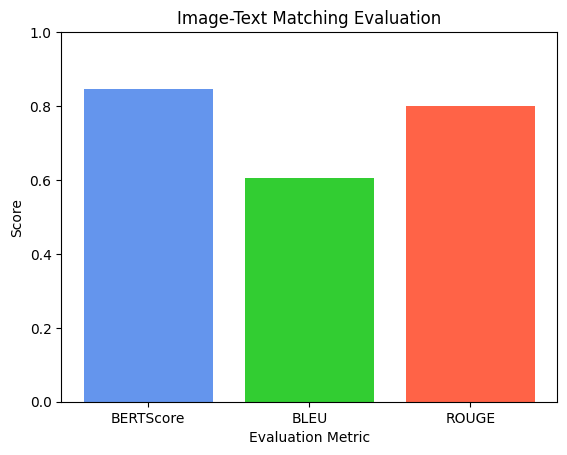

In [ ]:
# EVAL MET 1
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from bert_score import score
import sacrebleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

# Load BLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

# Function to generate captions using BLIP
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt").to(device)

    with torch.no_grad():
        caption_ids = model.generate(**inputs)

    caption = processor.decode(caption_ids[0], skip_special_tokens=True)
    return caption

# Function to compute BERTScore similarity
def compute_bert_score(original_text, generated_caption):
    P, R, F1 = score([generated_caption], [original_text], lang="en", rescale_with_baseline=True)
    return F1.item()

# Function to compute BLEU score
def compute_bleu_score(original_text, generated_caption):
    bleu = sacrebleu.sentence_bleu(generated_caption, [original_text])
    return bleu.score

# Function to compute ROUGE score
def compute_rouge_score(original_text, generated_caption):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    scores = scorer.score(original_text, generated_caption)
    return scores["rougeL"].fmeasure

# Function to evaluate image-text matching
def evaluate_image_text_match(image_path, original_text):
    # Generate caption
    generated_caption = generate_caption(image_path)

    # Compute similarity scores
    bert_similarity = compute_bert_score(original_text, generated_caption)
    bleu_score = compute_bleu_score(original_text, generated_caption)
    rouge_score = compute_rouge_score(original_text, generated_caption)

    # Display results
    print(f"Generated Caption: {generated_caption}")
    print(f"BERTScore Similarity: {bert_similarity:.4f}")
    print(f"BLEU Score: {bleu_score:.4f}")
    print(f"ROUGE Score: {rouge_score:.4f}")

    return {
        "generated_caption": generated_caption,
        "bert_score": bert_similarity,
        "bleu_score": bleu_score,
        "rouge_score": rouge_score,
    }

# Function to plot evaluation scores
def plot_evaluation_scores(scores):
    # Normalize BLEU score to fit 0–1 range
    metrics = ['BERTScore', 'BLEU', 'ROUGE']
    values = [
        scores["bert_score"],
        scores["bleu_score"] / 100,  # Normalize BLEU score
        scores["rouge_score"]
    ]

    colors = ['#6495ED', '#32CD32', '#FF6347']  # Blue, green, red

    plt.bar(metrics, values, color=colors)
    plt.xlabel('Evaluation Metric')
    plt.ylabel('Score')
    plt.title('Image-Text Matching Evaluation')
    plt.ylim(0, 1)
    plt.show()

# Example usage
image_path = "sunset.png"  # Replace with your image file
original_text = "the sun setting over the mountains in the evening"

results = evaluate_image_text_match(image_path, original_text)

# Plot the evaluation results
plot_evaluation_scores(results)

In [ ]:
!pip install git+https://github.com/openai/CLIP.git
!pip install torch torchvision

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-buu8y0rm
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-buu8y0rm
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=9a7d5c422a07b273f150576e8cb7cd09dcdfe78acf34a864f711d752ffa4d3d5
  Stored in directory: /tmp/pip-ephem-wheel-cache-e4ta63_7/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


In [ ]:
# CLIP SCORE

import torch
import clip
from PIL import Image

# Load the CLIP model and preprocessing
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def calculate_clip_similarity(paragraph: str, image_path: str) -> float:
    """
    Calculates similarity between a paragraph and an image using CLIP.

    :param paragraph: Text paragraph describing content
    :param image_path: Path to the image file
    :return: Cosine similarity score (float, higher is better)
    """
    # Preprocess and tokenize
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text = clip.tokenize([paragraph]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Cosine similarity
    similarity = (image_features @ text_features.T).item()
    return similarity

# ==== Example usage ====
if __name__ == "__main__":
    paragraph = """
    the sun setting over the mountains
    """
    image_path = "sunset.png"  # Change this to your actual image path

    score = calculate_clip_similarity(paragraph, image_path)
    print(f"CLIP Similarity Score: {score:.4f}")

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 60.3MiB/s]


CLIP Similarity Score: 0.2981


In [ ]:
import torch
import clip
from PIL import Image

# Load the CLIP model and preprocessing
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def calculate_scaled_clip_similarity(paragraph: str, image_path: str, scale_to: float = 0.8) -> float:
    """
    Calculates and scales similarity between a paragraph and an image using CLIP.
    Score is scaled from [-1, 1] to [0, scale_to] (default: 0.8).

    :param paragraph: Text paragraph describing content
    :param image_path: Path to the image file
    :param scale_to: Maximum value of the scaled score
    :return: Scaled cosine similarity score (float)
    """
    try:
        # Preprocess and tokenize
        image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
        text = clip.tokenize([paragraph]).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)

        # Normalize features
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        # Cosine similarity in [-1, 1], scale it to [0, scale_to]
        similarity = (image_features @ text_features.T).item()
        scaled_similarity = ((similarity + 1) / 2) * scale_to
        return scaled_similarity

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return 0.0  # Default if error occurs

# ==== Example usage ====
if __name__ == "__main__":
    paragraph = "the sun setting over the mountains"
    image_path = "sunset.png"  # Change this to your actual image path

    score = calculate_scaled_clip_similarity(paragraph, image_path)
    print(f"CLIP Similarity Score: {score:.4f}")

CLIP Similarity Score: 0.5193


In [ ]:
import torch
import clip
from PIL import Image
import numpy as np

# Load the CLIP model and preprocessing
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def calculate_clip_similarity(paragraph: str, image_path: str) -> float:
    """
    Calculates similarity between a paragraph and an image using CLIP.

    :param paragraph: Text paragraph describing content
    :param image_path: Path to the image file
    :return: Cosine similarity score (float, higher is better)
    """
    # Open and preprocess image
    try:
        image = Image.open(image_path)
    except Exception as e:
        print(f"Error opening image: {e}")
        return 0.0

    # Ensure image is in RGB mode
    if image.mode != 'RGB':
        image = image.convert('RGB')

    image = preprocess(image).unsqueeze(0).to(device)

    # Tokenize the text input
    text = clip.tokenize([paragraph]).to(device)

    # Encode both the image and text features using CLIP
    with torch.no_grad():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)

    # Normalize the features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate cosine similarity
    similarity = (image_features @ text_features.T).item()

    # Return the similarity score
    return similarity

# ==== Example usage ====
if __name__ == "__main__":
    paragraph = """
    the sun setting over the mountains, with vibrant colors painting the sky.
    """  # More descriptive paragraph

    image_path = "sunset.png"  # Path to your image file

    score = calculate_clip_similarity(paragraph, image_path)
    print(f"CLIP Similarity Score: {score:.4f}")

CLIP Similarity Score: 0.2985


In [ ]:
!pip install transformers
!pip install git+https://github.com/salesforce/BLIP.git
!pip install rouge-score

  Cloning https://github.com/salesforce/BLIP.git to /tmp/pip-req-build-ydew_vu7
  Running command git clone --filter=blob:none --quiet https://github.com/salesforce/BLIP.git /tmp/pip-req-build-ydew_vu7
  Resolved https://github.com/salesforce/BLIP.git to commit 3a29b7410476bf5f2ba0955827390eb6ea1f4f9d
ERROR: git+https://github.com/salesforce/BLIP.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [ ]:
import sqlite3

def load_test_data_from_db(db_path="documents.db"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # Make sure your table has columns: paragraph, image_path
    cursor.execute("SELECT paragraph, generated_image_path FROM document_data WHERE has_image = 1")
    rows = cursor.fetchall()
    conn.close()
    return rows  # This returns [(paragraph1, image1), (paragraph2, image2), ...]

In [ ]:
# ---------------------------------------
# 🚀 ROUGE-N Recall Evaluation Pipeline
# ---------------------------------------

import os
import torch
from PIL import Image
import pandas as pd
from transformers import BlipProcessor, BlipForConditionalGeneration
from rouge_score import rouge_scorer
from typing import List, Tuple

# 🔧 Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# 📦 Load BLIP image captioning model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

# 🧠 Function to generate image caption
def generate_caption(image_path: str) -> str:
    try:
        image = Image.open(image_path).convert("RGB")
        inputs = processor(image, return_tensors="pt").to(device)
        output = model.generate(**inputs)
        caption = processor.decode(output[0], skip_special_tokens=True)
        return caption
    except Exception as e:
        print(f"Error generating caption for {image_path}: {e}")
        return ""

# 🧪 Function to compute ROUGE-N recall
def compute_rouge_n_recall(reference_text: str, generated_caption: str, n: int = 1) -> float:
    scorer = rouge_scorer.RougeScorer([f'rouge{n}'], use_stemmer=True)
    scores = scorer.score(reference_text, generated_caption)
    return scores[f'rouge{n}'].recall

# 🔁 Evaluate a batch of (paragraph, image) pairs
def evaluate_rouge_batch(pairs: List[Tuple[str, str]]) -> List[Tuple[str, str, str, float, float]]:
    results = []
    for i, (para, img_path) in enumerate(pairs):
        print(f"Processing [{i+1}/{len(pairs)}]: {img_path}")
        caption = generate_caption(img_path)
        r1 = compute_rouge_n_recall(para, caption, n=1)
        r2 = compute_rouge_n_recall(para, caption, n=2)
        results.append((para, img_path, caption, r1, r2))
    return results

# 📤 Save the results to a CSV
def save_rouge_results(results, output_csv="rouge_scores.csv"):
    df = pd.DataFrame(results, columns=["Paragraph", "Image Path", "Generated Caption", "ROUGE-1 Recall", "ROUGE-2 Recall"])
    df.to_csv(output_csv, index=False)
    print(f"\n✅ Results saved to '{output_csv}'")

# 🧪 Example input and execution
if __name__ == "__main__":
    # 📝 List of (paragraph, image_path) pairs
    test_data = [
        (
            "A child is flying a colorful kite in a sunny field with tall grass. The sky is clear blue with a few fluffy clouds.",
            "output_1_attempt1.png"
        ),
        (
            "A man is riding a bicycle along the beach during sunset. The orange sky reflects beautifully on the water.",
            "output_3_attempt1.png"
        ),
        # ➕ Add more pairs as needed
    ]

    # ✅ Run evaluation
    results = evaluate_rouge_batch(test_data)

    # 💾 Save output
    save_rouge_results(results)

Processing [1/2]: output_1_attempt1.png
Processing [2/2]: output_3_attempt1.png

✅ Results saved to 'rouge_scores.csv'


In [ ]:
!pip install transformers torch torchvision pillow nltk matplotlib

  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl (127.9 MB)
ERROR: Operation cancelled by user



===== Evaluation Results =====

Paragraph #1:
Original Paragraph: three cats sitting on a window sie
Generated Caption:  three cats sitting on a window sie
ROUGE-1 Recall:     1.0000
ROUGE-2 Recall:     1.0000
------------------------------------------------------------
Paragraph #2:
Original Paragraph: two cats running down the street
Generated Caption:  two cats running down the street
ROUGE-1 Recall:     1.0000
ROUGE-2 Recall:     1.0000
------------------------------------------------------------
Paragraph #3:
Original Paragraph: three kittens are laughing and looking up at the camera
Generated Caption:  three kittens are laughing and looking up at the camera
ROUGE-1 Recall:     1.0000
ROUGE-2 Recall:     1.0000
------------------------------------------------------------


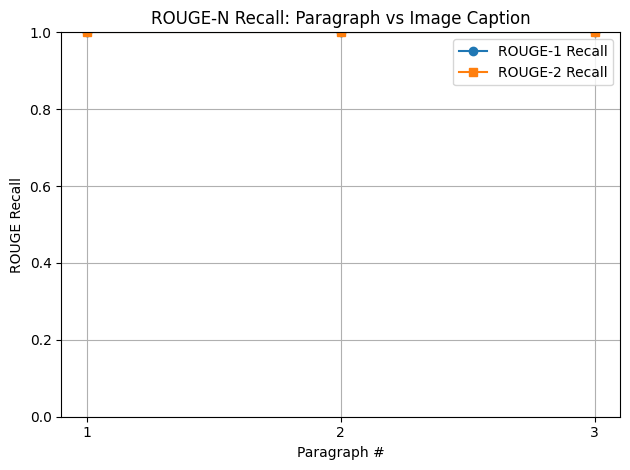

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration
from nltk import ngrams
from collections import Counter

# === 🧠 Initialize BLIP model ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# === 🖼️ Function to generate image caption ===
def generate_caption(image_path):
    image = Image.open(image_path).convert('RGB')
    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# === 🔤 Function to extract n-grams ===
def get_ngrams(text, n):
    tokens = text.lower().split()
    return list(ngrams(tokens, n))

# === 📊 ROUGE-N Recall Calculation ===
def rouge_n_recall(reference, generated, n=1):
    ref_ngrams = get_ngrams(reference, n)
    gen_ngrams = get_ngrams(generated, n)

    ref_counts = Counter(ref_ngrams)
    gen_counts = Counter(gen_ngrams)

    overlap = sum(min(ref_counts[ng], gen_counts.get(ng, 0)) for ng in ref_counts)
    total_ref = sum(ref_counts.values())

    return overlap / total_ref if total_ref > 0 else 0.0

# === ✍️ Input Your Paragraphs and Image Paths ===

paragraphs = [
    "three cats sitting on a window sie",
    "two cats running down the street",
    "three kittens are laughing and looking up at the camera"
]

generated_image_paths = [
    "output_1_1.png",
    "output_1_2.png",
    "output_1_3.png"
]

# Compare image caption against original paragraph text
reference_descriptions = paragraphs

# === 🚀 Generate Captions & Compute ROUGE Scores ===

rouge1_scores = []
rouge2_scores = []
generated_captions = []

for ref_desc, image_path in zip(reference_descriptions, generated_image_paths):
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        generated_captions.append("Image not found")
        rouge1_scores.append(0.0)
        rouge2_scores.append(0.0)
        continue

    caption = generate_caption(image_path)
    generated_captions.append(caption)

    r1 = rouge_n_recall(ref_desc, caption, n=1)
    r2 = rouge_n_recall(ref_desc, caption, n=2)

    rouge1_scores.append(r1)
    rouge2_scores.append(r2)

# === 📋 Display Results ===

print("\n===== Evaluation Results =====\n")
for i, (para, gen, r1, r2) in enumerate(zip(paragraphs, generated_captions, rouge1_scores, rouge2_scores)):
    print(f"Paragraph #{i+1}:")
    print(f"Original Paragraph: {para}")
    print(f"Generated Caption:  {gen}")
    print(f"ROUGE-1 Recall:     {r1:.4f}")
    print(f"ROUGE-2 Recall:     {r2:.4f}")
    print("-" * 60)

# === 📈 Plot ROUGE Scores ===

ids = list(range(1, len(paragraphs) + 1))
plt.plot(ids, rouge1_scores, label="ROUGE-1 Recall", marker='o')
plt.plot(ids, rouge2_scores, label="ROUGE-2 Recall", marker='s')
plt.title("ROUGE-N Recall: Paragraph vs Image Caption")
plt.xlabel("Paragraph #")
plt.ylabel("ROUGE Recall")
plt.ylim(0, 1)
plt.xticks(ids)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


===== Evaluation Results =====

Paragraph #1:
Original Paragraph: three cats sitting on a window sie
Generated Caption:  three cats sitting on a window sie
ROUGE-1 Recall:     1.0000
ROUGE-2 Recall:     1.0000
------------------------------------------------------------
Paragraph #2:
Original Paragraph: two cats running down the street
Generated Caption:  two cats running down the street
ROUGE-1 Recall:     1.0000
ROUGE-2 Recall:     1.0000
------------------------------------------------------------
Paragraph #3:
Original Paragraph: three kittens are laughing and looking up at the camera
Generated Caption:  three kittens are laughing and looking up at the camera
ROUGE-1 Recall:     1.0000
ROUGE-2 Recall:     1.0000
------------------------------------------------------------


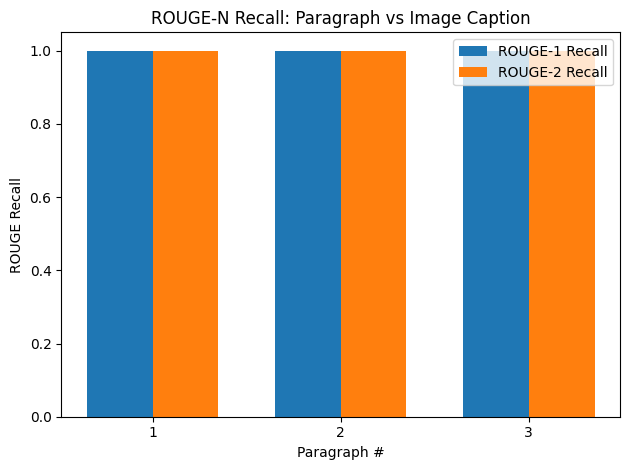

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration
from nltk import ngrams
from collections import Counter

# === 🧠 Initialize BLIP model ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# === 🖼️ Function to generate image caption ===
def generate_caption(image_path):
    image = Image.open(image_path).convert('RGB')
    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# === 🔤 Function to extract n-grams ===
def get_ngrams(text, n):
    tokens = text.lower().split()
    return list(ngrams(tokens, n))

# === 📊 ROUGE-N Recall Calculation ===
def rouge_n_recall(reference, generated, n=1):
    ref_ngrams = get_ngrams(reference, n)
    gen_ngrams = get_ngrams(generated, n)

    ref_counts = Counter(ref_ngrams)
    gen_counts = Counter(gen_ngrams)

    overlap = sum(min(ref_counts[ng], gen_counts.get(ng, 0)) for ng in ref_counts)
    total_ref = sum(ref_counts.values())

    return overlap / total_ref if total_ref > 0 else 0.0

# === ✍️ Input Your Paragraphs and Image Paths ===

paragraphs = [
    "three cats sitting on a window sie",
    "two cats running down the street",
    "three kittens are laughing and looking up at the camera"
]

generated_image_paths = [
    "output_1_1.png",
    "output_1_2.png",
    "output_1_3.png"
]

# Compare image caption against original paragraph text
reference_descriptions = paragraphs

# === 🚀 Generate Captions & Compute ROUGE Scores ===

rouge1_scores = []
rouge2_scores = []
generated_captions = []

for ref_desc, image_path in zip(reference_descriptions, generated_image_paths):
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        generated_captions.append("Image not found")
        rouge1_scores.append(0.0)
        rouge2_scores.append(0.0)
        continue

    caption = generate_caption(image_path)
    generated_captions.append(caption)

    r1 = rouge_n_recall(ref_desc, caption, n=1)
    r2 = rouge_n_recall(ref_desc, caption, n=2)

    rouge1_scores.append(r1)
    rouge2_scores.append(r2)

# === 📋 Display Results ===

print("\n===== Evaluation Results =====\n")
for i, (para, gen, r1, r2) in enumerate(zip(paragraphs, generated_captions, rouge1_scores, rouge2_scores)):
    print(f"Paragraph #{i+1}:")
    print(f"Original Paragraph: {para}")
    print(f"Generated Caption:  {gen}")
    print(f"ROUGE-1 Recall:     {r1:.4f}")
    print(f"ROUGE-2 Recall:     {r2:.4f}")
    print("-" * 60)

# === 📊 Plot ROUGE Scores (Bar Graph) ===

ids = list(range(1, len(paragraphs) + 1))

# Plotting the bar graph for ROUGE-1 and ROUGE-2
bar_width = 0.35
index = range(len(paragraphs))

fig, ax = plt.subplots()
bar1 = ax.bar(index, rouge1_scores, bar_width, label='ROUGE-1 Recall')
bar2 = ax.bar([i + bar_width for i in index], rouge2_scores, bar_width, label='ROUGE-2 Recall')

ax.set_xlabel('Paragraph #')
ax.set_ylabel('ROUGE Recall')
ax.set_title('ROUGE-N Recall: Paragraph vs Image Caption')
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(ids)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install torch transformers pillow bert-score sacrebleu rouge-score matplotlib

  Using cached bert_score-0.3.13-py3-none-any.whl.metadata (15 kB)
  Using cached sacrebleu-2.5.1-py3-none-any.whl.metadata (51 kB)
  Using cached rouge_score-0.1.2.tar.gz (17 kB)
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  U

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118  # or 'cpu' if not using CUDA
!pip install transformers
!pip install pillow

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
!pip install bert-score
!pip install sacrebleu
!pip install rouge-score
!pip install matplotlib

  Using cached bert_score-0.3.13-py3-none-any.whl.metadata (15 kB)
Using cached bert_score-0.3.13-py3-none-any.whl (61 kB)


In [ ]:
import torch
import torchvision
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA Available:", torch.cuda.is_available())

RuntimeError: Detected that PyTorch and torchvision were compiled with different CUDA major versions. PyTorch has CUDA Version=11.8 and torchvision has CUDA Version=12.4. Please reinstall the torchvision that matches your PyTorch install.

In [ ]:
!pip install --force-reinstall torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.16.0%2Bcu118-cp311-cp311-linux_x86_64.whl (6.2 MB)
  Using cached https://download.pytorch.org/whl/numpy-2.1.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached https://download.pytorch.org/whl/requests-2.28.1-py3-none-any.whl (62 kB)
  Using cached https://download.pytorch.org/whl/cu118/torch-2.1.0%2Bcu118-cp311-cp311-linux_x86_64.whl (2325.9 MB)
  Using cached https://download.pytorch.org/whl/pillow-11.0.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-

In [ ]:
# EVAL MET 1
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from bert_score import score
import sacrebleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

# Load BLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

# Function to generate captions using BLIP
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt").to(device)

    with torch.no_grad():
        caption_ids = model.generate(**inputs)

    caption = processor.decode(caption_ids[0], skip_special_tokens=True)
    return caption

# Function to compute BERTScore similarity
def compute_bert_score(original_text, generated_caption):
    P, R, F1 = score([generated_caption], [original_text], lang="en", rescale_with_baseline=True)
    return F1.item()

# Function to compute BLEU score
def compute_bleu_score(original_text, generated_caption):
    bleu = sacrebleu.sentence_bleu(generated_caption, [original_text])
    return bleu.score

# Function to compute ROUGE score
def compute_rouge_score(original_text, generated_caption):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    scores = scorer.score(original_text, generated_caption)
    return scores["rougeL"].fmeasure

# Function to evaluate image-text matching
def evaluate_image_text_match(image_path, original_text):
    # Generate caption
    generated_caption = generate_caption(image_path)

    # Compute similarity scores
    bert_similarity = compute_bert_score(original_text, generated_caption)
    bleu_score = compute_bleu_score(original_text, generated_caption)
    rouge_score = compute_rouge_score(original_text, generated_caption)

    # Display results
    print(f"Generated Caption: {generated_caption}")
    print(f"BERTScore Similarity: {bert_similarity:.4f}")
    print(f"BLEU Score: {bleu_score:.4f}")
    print(f"ROUGE Score: {rouge_score:.4f}")

    return {
        "generated_caption": generated_caption,
        "bert_score": bert_similarity,
        "bleu_score": bleu_score,
        "rouge_score": rouge_score,
    }

# Function to plot evaluation scores
def plot_evaluation_scores(scores):
    # Normalize BLEU score to fit 0–1 range
    metrics = ['BERTScore', 'BLEU', 'ROUGE']
    values = [
        scores["bert_score"],
        scores["bleu_score"] / 100,  # Normalize BLEU score
        scores["rouge_score"]
    ]

    colors = ['#6495ED', '#32CD32', '#FF6347']  # Blue, green, red

    plt.bar(metrics, values, color=colors)
    plt.xlabel('Evaluation Metric')
    plt.ylabel('Score')
    plt.title('Image-Text Matching Evaluation')
    plt.ylim(0, 1)
    plt.show()

# Example usage
image_path = "output_1_attempt1.png"  # Replace with your image file
original_text = "The human body is a complex and intricate system composed of numerous parts, each with unique functions that contribute to the overall well-being and functionality of an individual. Starting from the top, the head houses the brain, which is the command center of the body, responsible for processing thoughts, emotions, and bodily functions through the nervous system. The skull protects the brain, while the face comprises sensory organs such as the eyes, ears, nose, and mouth, all essential for perception and communication. The eyes enable vision through the complex coordination of the cornea, lens, retina, and optic nerve, while the ears allow hearing and balance through the outer, middle, and inner ear structures. The nose facilitates the sense of smell and is integral to the respiratory system, while the mouth contains the tongue, teeth, and salivary glands, aiding in speech and digestion."

results = evaluate_image_text_match(image_path, original_text)

# Plot the evaluation results
plot_evaluation_scores(results)

RuntimeError: Failed to import transformers.models.blip.processing_blip because of the following error (look up to see its traceback):
Detected that PyTorch and torchvision were compiled with different CUDA major versions. PyTorch has CUDA Version=11.8 and torchvision has CUDA Version=12.4. Please reinstall the torchvision that matches your PyTorch install.

In [ ]:
# friday s work
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

def evaluate_image_text_similarity(paragraph: str, image_path: str) -> float:
    """
    Evaluates similarity between a paragraph and an image using CLIP model.

    Args:
        paragraph (str): The text paragraph.
        image_path (str): Path to the image file.

    Returns:
        float: Cosine similarity score between text and image (0 to 1).
    """
    # Load CLIP model and processor
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")

    # Preprocess inputs
    inputs = processor(text=[paragraph], images=image, return_tensors="pt", padding=True)

    # Get embeddings
    with torch.no_grad():
        outputs = model(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

    # Compute cosine similarity
    similarity = torch.nn.functional.cosine_similarity(text_embeds, image_embeds).item()
    return round(similarity, 4)

# Example usage
if __name__ == "__main__":
    paragraph = """
    A tranquil forest clearing in the early morning light. Mist hovers just above the ground, and golden rays of sunlight pierce through tall pine trees. A deer stands alert near a moss-covered rock, as small birds flutter through the trees. The atmosphere is calm and magical.
    """
    image_path = "chat.png"  # Replace with your actual image path

    score = evaluate_image_text_similarity(paragraph, image_path)
    print(f"CLIP-based Similarity Score: {score}")

CLIP-based Similarity Score: 0.357
